---
title: "📐The Hidden Geometry of Software Coupling (Part 1)"
date: 2026-03-09 00:11:50 -0500
categories:
  - sdlc
  - architecture
  - coupling
  - metrics
author: steven
---

# 📐 The Hidden Geometry of Software Coupling
### Part 1 — The Metrics That Predict Architectural Failure


In [1]:
# ============================================================
# SETUP — Run this first!
# ============================================================

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
from matplotlib.ticker import FuncFormatter

print("✅ matplotlib version:", mpl.__version__)
print("✅ Setup complete!")

# ============================================================
# 🎨 ARTICLE STYLE + SHARED CONFIGURATION
# ============================================================

PALETTE = {
    "paper_bg": "#EFE7D6",
    "plot_bg": "#E6DDCB",
    "grid": "#8E8474",
    "axis": "#2E4369",
    "zone_pain": "#B25E5E",
    "zone_useless": "#9086C4",
    "main_seq": "#4DAA57",
    "guide": "#8A8276",
    "label_bg": "#FCF5E5",
    "danger_text": "#8B0000",
    "distance_text": "#4F4A43",
    "stable_band": "#91B98A",
    "mostly_stable_band": "#B9C98B",
    "borderline_band": "#D9BF74",
    "volatile_band": "#C97C7C",
}

MODULES = [
    {"name": "Database Schema",         "I": 0.10, "A": 0.05, "color": "#E53935"},
    {"name": "Unused Interfaces",       "I": 0.70, "A": 0.95, "color": "#1E40FF"},
    {"name": "Core Domain Interfaces",  "I": 0.22, "A": 0.78, "color": "#0B8A0B"},
    {"name": "Domain Model",            "I": 0.38, "A": 0.52, "color": "#1E8E1E"},
    {"name": "Service Layer",           "I": 0.68, "A": 0.36, "color": "#169C16"},
    {"name": "Perfect Balance",         "I": 0.50, "A": 0.50, "color": "#006400"},
    {"name": "API Gateway",             "I": 0.80, "A": 0.40, "color": "#F4A000"},
    {"name": "Shared Utilities",        "I": 0.34, "A": 0.44, "color": "#8A6D3B"},
    {"name": "Integration Adapter",     "I": 0.88, "A": 0.12, "color": "#8C564B"},
]

for m in MODULES:
    m["D"] = abs(m["A"] + m["I"] - 1)

LABEL_OFFSETS = {
    "Database Schema":        (0.040,  0.000, "left",  "center"),
    "Unused Interfaces":      (0.020, -0.002, "left",  "center"),
    "Core Domain Interfaces": (0.030,  0.028, "left",  "center"),
    "Domain Model":           (0.020,  0.004, "left",  "center"),
    "Service Layer":          (0.022, -0.004, "left",  "center"),
    "Perfect Balance":        (0.020, -0.018, "left",  "center"),
    "API Gateway":            (0.020,  0.034, "left",  "center"),
    "Shared Utilities":       (0.018, -0.030, "left",  "center"),
    "Integration Adapter":    (-0.022, -0.040, "right", "center"),
}

SHOW_DISTANCE_FOR = {
    "Database Schema",
    "Unused Interfaces",
    "Service Layer",
    "API Gateway",
    "Shared Utilities",
    "Integration Adapter",
}

DISTANCE_LABEL_OFFSETS = {
    "Database Schema":      (0.010,  0.020),
    "Unused Interfaces":    (-0.020, -0.008),
    "Service Layer":        (0.008, -0.020),
    "API Gateway":          (0.016, -0.014),
    "Shared Utilities":     (-0.020, -0.008),
    "Integration Adapter":  (-0.010, -0.018),
}

CURVE_CA_VALUES = [0, 1, 2, 3, 5, 8, 10, 15, 20]
CURVE_COLORS = ["#9D1A1A", "#FF2626", "#FF6A00", "#E58A00", "#5EA400", "#16A34A", "#0EA5A8", "#2563EB", "#7C3AED"]

FIGSIZE_MAIN = (10.5, 8.2)
FIGSIZE_DETAIL = (11.8, 8.8)
FIGSIZE_CURVES = (12.8, 8.4)

mpl.rcParams.update({
    "figure.facecolor": PALETTE["paper_bg"],
    "axes.facecolor": PALETTE["plot_bg"],
    "axes.edgecolor": PALETTE["axis"],
    "axes.labelcolor": PALETTE["axis"],
    "axes.titlecolor": PALETTE["axis"],
    "axes.titleweight": "semibold",
    "xtick.color": PALETTE["axis"],
    "ytick.color": PALETTE["axis"],
    "text.color": PALETTE["axis"],
    "font.size": 12,
    "font.family": "DejaVu Sans",
})

def tick_fmt(x, pos):
    if abs(x - round(x)) < 1e-9:
        return str(int(round(x)))
    return f"{x:.1f}"

TICK_FORMATTER = FuncFormatter(tick_fmt)

def project_to_main_sequence(i_value: float, a_value: float):
    proj_i = (i_value - a_value + 1) / 2
    proj_i = max(0.0, min(1.0, proj_i))
    proj_a = 1.0 - proj_i
    return proj_i, proj_a

def style_axes(ax, title: str, subtitle: str | None = None):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("I (Instability) →", fontsize=16, labelpad=12, color=PALETTE["axis"])
    ax.set_ylabel("A (Abstractness) →", fontsize=16, labelpad=18, color=PALETTE["axis"])
    ax.set_xticks(np.arange(0, 1.01, 0.1))
    ax.set_yticks(np.arange(0, 1.01, 0.1))
    ax.xaxis.set_major_formatter(TICK_FORMATTER)
    ax.yaxis.set_major_formatter(TICK_FORMATTER)
    ax.grid(True, color=PALETTE["grid"], alpha=0.20, linewidth=1)
    ax.tick_params(length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(PALETTE["axis"])
    ax.spines["bottom"].set_color(PALETTE["axis"])
    ax.set_title(title, fontsize=23, fontstyle="italic", family="DejaVu Serif", pad=28, color=PALETTE["axis"])
    if subtitle:
        ax.text(
            0.5, 1.04, subtitle,
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=18,
            family="DejaVu Sans Mono",
            color=PALETTE["axis"],
        )

def draw_zones(ax):
    pain = Polygon([(0, 0), (0, 0.5), (0.5, 0)], closed=True,
                   facecolor=PALETTE["zone_pain"], edgecolor="none", alpha=0.22, zorder=1)
    useless = Polygon([(1, 1), (1, 0.5), (0.5, 1)], closed=True,
                      facecolor=PALETTE["zone_useless"], edgecolor="none", alpha=0.24, zorder=1)
    ax.add_patch(pain)
    ax.add_patch(useless)

    ax.text(
        0.24, 0.050, "ZONE OF PAIN\n(Stable + Concrete)",
        ha="center", va="center",
        fontsize=13, family="DejaVu Serif", fontweight="semibold",
        color=PALETTE["danger_text"], zorder=3
    )
    ax.text(
        0.76, 0.955, "ZONE OF USELESSNESS\n(Unstable + Abstract)",
        ha="center", va="center",
        fontsize=13, family="DejaVu Serif", fontweight="semibold",
        color=PALETTE["danger_text"], zorder=3
    )

def draw_main_sequence(ax, label: str = "Main Sequence"):
    ax.plot([0, 1], [1, 0], color=PALETTE["main_seq"], linewidth=4, zorder=2, label=label)

def build_base_legend(include_distance_sample: bool = False):
    handles = [
        Line2D([0], [0], color=PALETTE["zone_pain"], linewidth=8, alpha=0.22, label="Zone of Pain"),
        Line2D([0], [0], color=PALETTE["zone_useless"], linewidth=8, alpha=0.24, label="Zone of Uselessness"),
        Line2D([0], [0], color=PALETTE["main_seq"], linewidth=4, label="Main Sequence"),
    ]
    if include_distance_sample:
        handles.append(
            Line2D([0], [0], marker="o", markersize=10, color=PALETTE["main_seq"],
                   linestyle="--", linewidth=1.2, label="D = Distance from Main Sequence")
        )
    return handles

def render_main_sequence_conceptual():
    fig, ax = plt.subplots(figsize=FIGSIZE_MAIN)
    draw_zones(ax)
    draw_main_sequence(ax)

    ax.plot([0.50, 0.60], [0.50, 0.60], color=PALETTE["main_seq"],
            linestyle=(0, (2, 3)), linewidth=1.5, alpha=0.85, zorder=2)
    ax.scatter([0.60], [0.60], s=140, color=PALETTE["main_seq"], zorder=4)
    ax.text(
        0.45, 0.625, "D = Distance from Main Sequence",
        ha="left", va="center",
        fontsize=11, family="DejaVu Sans Mono",
        color=PALETTE["axis"], zorder=4
    )

    style_axes(ax, "Main Sequence", "A + I = 1")
    ax.legend(
        handles=build_base_legend(include_distance_sample=True),
        frameon=False, loc="upper left", bbox_to_anchor=(1.08, 1.01),
        labelcolor=PALETTE["axis"], fontsize=12, borderaxespad=0.
    )
    fig.tight_layout(rect=[0, 0, 0.90, 1], pad=1.2)
    plt.show()

def render_distance_from_main_sequence():
    fig, ax = plt.subplots(figsize=FIGSIZE_DETAIL)
    draw_zones(ax)
    draw_main_sequence(ax)

    for m in MODULES:
        proj_i, proj_a = project_to_main_sequence(m["I"], m["A"])
        ax.plot(
            [m["I"], proj_i], [m["A"], proj_a],
            color=PALETTE["guide"], linewidth=1.2,
            linestyle=(0, (3, 3)), alpha=0.50, zorder=2
        )
        ax.scatter([proj_i], [proj_a], s=28, color=PALETTE["guide"], alpha=0.28, zorder=3)

    for m in MODULES:
        ax.scatter([m["I"]], [m["A"]], s=320, color=m["color"],
                   edgecolor="white", linewidth=2.5, zorder=4)
        dx, dy, ha, va = LABEL_OFFSETS[m["name"]]
        ax.text(
            m["I"] + dx, m["A"] + dy, m["name"],
            ha=ha, va=va, fontsize=11,
            color=PALETTE["axis"], zorder=5, clip_on=True
        )

    for m in MODULES:
        if m["name"] not in SHOW_DISTANCE_FOR or m["D"] <= 0.001:
            continue
        proj_i, proj_a = project_to_main_sequence(m["I"], m["A"])
        mid_i = (m["I"] + proj_i) / 2
        mid_a = (m["A"] + proj_a) / 2
        ddx, ddy = DISTANCE_LABEL_OFFSETS.get(m["name"], (0.0, 0.0))
        ax.text(
            mid_i + ddx, mid_a + ddy, f"D={m['D']:.2f}",
            fontsize=10, color=PALETTE["distance_text"],
            ha="center", va="center", zorder=6,
            bbox=dict(boxstyle="round,pad=0.18,rounding_size=0.04",
                      fc=PALETTE["label_bg"], ec="none", alpha=0.90)
        )

    style_axes(ax, "Distance from Main Sequence", "A + I = 1")
    ax.legend(
        handles=build_base_legend(include_distance_sample=False),
        frameon=False, loc="upper left", bbox_to_anchor=(1.08, 1.01),
        labelcolor=PALETTE["axis"], fontsize=12, borderaxespad=0.
    )
    fig.tight_layout(rect=[0, 0, 0.90, 1], pad=1.2)
    plt.show()

def render_instability_curves():
    fig, ax = plt.subplots(figsize=FIGSIZE_CURVES)

    bands = [
        (0.00, 0.25, PALETTE["stable_band"], "Stable", "0.0 < I ≤ 0.25"),
        (0.25, 0.50, PALETTE["mostly_stable_band"], "Mostly Stable", "0.25 < I ≤ 0.50"),
        (0.50, 0.75, PALETTE["borderline_band"], "Borderline", "0.50 < I ≤ 0.75"),
        (0.75, 1.00, PALETTE["volatile_band"], "Volatile", "0.75 < I ≤ 1.0"),
    ]
    for y0, y1, color, _, _ in bands:
        ax.axhspan(y0, y1, color=color, alpha=0.10, zorder=0)

    for y in [0.25, 0.50, 0.75]:
        ax.axhline(y, color=PALETTE["grid"], linewidth=1.5, linestyle=(0, (6, 4)), alpha=0.45, zorder=1)

    ce = np.linspace(0, 20, 401)
    legend_handles = []
    for ca, color in zip(CURVE_CA_VALUES, CURVE_COLORS):
        if ca == 0:
            i = np.where(ce > 0, 1.0, np.nan)
        else:
            i = ce / (ce + ca)
        ax.plot(ce, i, color=color, linewidth=2.4, zorder=3)
        x_lab = 2.5 if ca == 0 else min(14.5, max(2.0, ca * 0.85 + 2.0))
        y_lab = 1.0 if ca == 0 else x_lab / (x_lab + ca)
        if ca == 0:
            y_lab = 1.0
        ax.text(
            x_lab, y_lab + (0.02 if ca < 5 else -0.02),
            f"Ca={ca}",
            color=color, fontsize=11, fontweight="semibold",
            family="DejaVu Serif"
        )
        legend_handles.append(Line2D([0], [0], color=color, linewidth=6, label=f"Ca = {ca}"))

    x_text = 20.45
    ax.text(x_text, 0.125, "STABLE", color="#2D7A32", rotation=90, va="center", ha="left",
            fontsize=10, fontweight="semibold")
    ax.text(x_text, 0.375, "MOSTLY STABLE", color="#789C2E", rotation=90, va="center", ha="left",
            fontsize=10, fontweight="semibold")
    ax.text(x_text, 0.625, "BORDERLINE", color="#A06F00", rotation=90, va="center", ha="left",
            fontsize=10, fontweight="semibold")
    ax.text(x_text, 0.875, "VOLATILE", color="#A12F2F", rotation=90, va="center", ha="left",
            fontsize=10, fontweight="semibold")

    ax.set_xlim(0, 20)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Ce (Efferent Coupling)", fontsize=18, labelpad=12, color=PALETTE["axis"])
    ax.set_ylabel("I = Instability", fontsize=18, labelpad=14, color=PALETTE["axis"])
    ax.set_xticks([0, 5, 10, 15, 20])
    ax.set_yticks([0, 0.25, 0.50, 0.75, 1.0])
    ax.yaxis.set_major_formatter(TICK_FORMATTER)
    ax.grid(True, color=PALETTE["grid"], alpha=0.14, linewidth=1)
    ax.tick_params(length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(PALETTE["axis"])
    ax.spines["bottom"].set_color(PALETTE["axis"])
    ax.set_title("Coupling Metrics\nInstability Curves", fontsize=24, fontweight="semibold",
                 family="DejaVu Serif", pad=20, color=PALETTE["axis"])

    ax.legend(
        handles=legend_handles,
        title="Ca Values",
        loc="center left",
        bbox_to_anchor=(-0.23, 0.45),
        frameon=True,
        facecolor=PALETTE["label_bg"],
        edgecolor="none",
        title_fontsize=12,
        fontsize=10
    )

    fig.text(
        0.50, 0.03, r"Figure 2: How Instability (I) varies with coupling    $I = \dfrac{C_e}{C_e + C_a}$",
        ha="center", va="center",
        fontsize=14, family="DejaVu Serif", color=PALETTE["axis"],
        bbox=dict(boxstyle="round,pad=0.45", fc="#C7D6EF", ec="#8AA5D1", alpha=0.95)
    )

    fig.tight_layout(rect=[0.05, 0.07, 0.92, 0.98])
    plt.show()

print("🎨 Configuration loaded")


✅ matplotlib version: 3.10.8
✅ Setup complete!
🎨 Configuration loaded


## 📃Introduction

Software engineers love to talk about architecture in qualitative terms.

- *“This module feels tightly coupled”*
- *“That dependency seems risky”*
- *“This design is flexible”*

But beneath those instincts lies something far more concrete
* The **structure of software systems can be measured**
* Architectural problems can be predicted **long before production failures reveal them**.

* The formulas behind these metrics have been around since the 1990s
* They require no machine learning
* Just counting (...and occasionally a little division)


## 🗿The Architecture That Was “Good Enough”… Until It Opened a Hellmouth 👹

"For the first six months, even a year, everything felt fast.  Our Ruby-on-Rails application was humming along."
* Features shipped quickly.
* Bug fixes took hours, not days.
* Engineers felt productive.

>Then, something strange started happening; it began to shift:
* A simple change began taking longer.
* A feature that should have touched one component suddenly required edits across:
  - seemingly-unrelated models and controllers
  - background jobs
  - serializers
  - service classes
  - many tests scattered across the codebase, some that seem unrelated.

_Then the real symptoms appeared:_
* New engineers joined the team and couldn't make heads or tails of the system.
* Bug fixes triggered unrelated failures.
* A “small refactor” broke three features nobody expected to be connected.
* Every change started to feel dangerous.

---

Eventually they bring in an architect, who spends a little while looking at our software and running various tools.  He tells us:

> Your problem isn’t Rails. Your problem is **coupling**.
> All the software enginners had heard of this

Some people remember this from _Software Engineering Principles_ (or whatever the course/book/article you read about this).  It maybe have come up a few times since, but never _exactly quantified_.  Now here it is in the real world.

The application had quietly evolved into something **infamous**:

### A Tightly Coupled Monolith

>  It's a simple complex system.  Because it's simple, it's prone to cascades, and because it's complex, you can't predict what's going to fail. Or how. -- _"The Expanse"_

* A change almost anywhere could trigger side-effects somewhere else.
* Features that should have touched one module required edits across five.
* Bug fixes became archaeology.
### And the surprising part?
* These structural problems weren't mysterious.
* They were **measurable**.
___

## 📐 The Two Numbers That Explain Most Architecture

Nearly every structural coupling metric derives from two simple counts.

```text
        Who depends on me?
                ↑
               Ca
                │
                ● GIVEN MODULE/PACKAGE
                │
               Ce
                ↓
        Upon whom do I depend?
```

### Afferent Coupling (Ca)

```text
Ca = number of external modules that depend on this one
```

Afferent coupling measures **responsibility**.

If many modules depend on you, your stability matters.

Break this module, and others break too.

Modules with high Ca become **structural anchors**.

### Efferent Coupling (Ce)

```text
Ce = number of external modules this module depends on
```

Efferent coupling measures **vulnerability**.

The more dependencies you have, the more ways your code can break.

Every dependency introduces:

- version risk
- semantic assumptions
- upgrade friction

Dependencies are powerful.

But they are never free.

### 🧮 A Simple Analogy

These metrics behave like a financial balance sheet.

| Metric                     | Analogy                        |
|----------------------------|--------------------------------|
| `Ca` *(Afferent Coupling)* | Creditors (who depends on you) |
| `Ce` *(Efferent Coupling)* | Debts (who you depend on)      |

* Modules with many creditors must be **_stable_**.
* Modules with many debts are inherently **_fragile_**.
---

## 🧭 The Instability Index (I)
<img src="../assets/images/metrics-instability-fig1-overview.png"/>

From Ca and Ce we derive a powerful ratio.

```text
I = Ce / (Ce + Ca)
```

Instability ranges from **0 to 1**.

| I Range | Stability | Meaning | Change Strategy |
|---|---|---|---|
| 0.0 ≤ I < 0.25 | Stable | Many dependents, few dependencies | Change with care |
| 0.25 ≤ I < 0.50 | Balanced | Healthy structural position | Normal dev pace |
| 0.50 ≤ I < 0.75 | Borderline | Dependency heavy | Monitor closely |
| 0.75 ≤ I ≤ 1.0 | Unstable | Few dependents, many dependencies | Refactor freely |

The graph below shows how instability changes as **Ce** grows for different fixed values of **Ca**.

Low **Ca** produces curves that rise very quickly toward volatility.
Higher **Ca** dampens that rise, making the same increase in **Ce** less destabilizing.

This leads to one of the most important architectural principles.

### Stable Dependencies Principle

Dependencies should flow **toward stability**.

```text
unstable modules  →  stable modules
```

When stable modules depend on unstable ones, architectural fragility appears quickly.


## Instability Curves

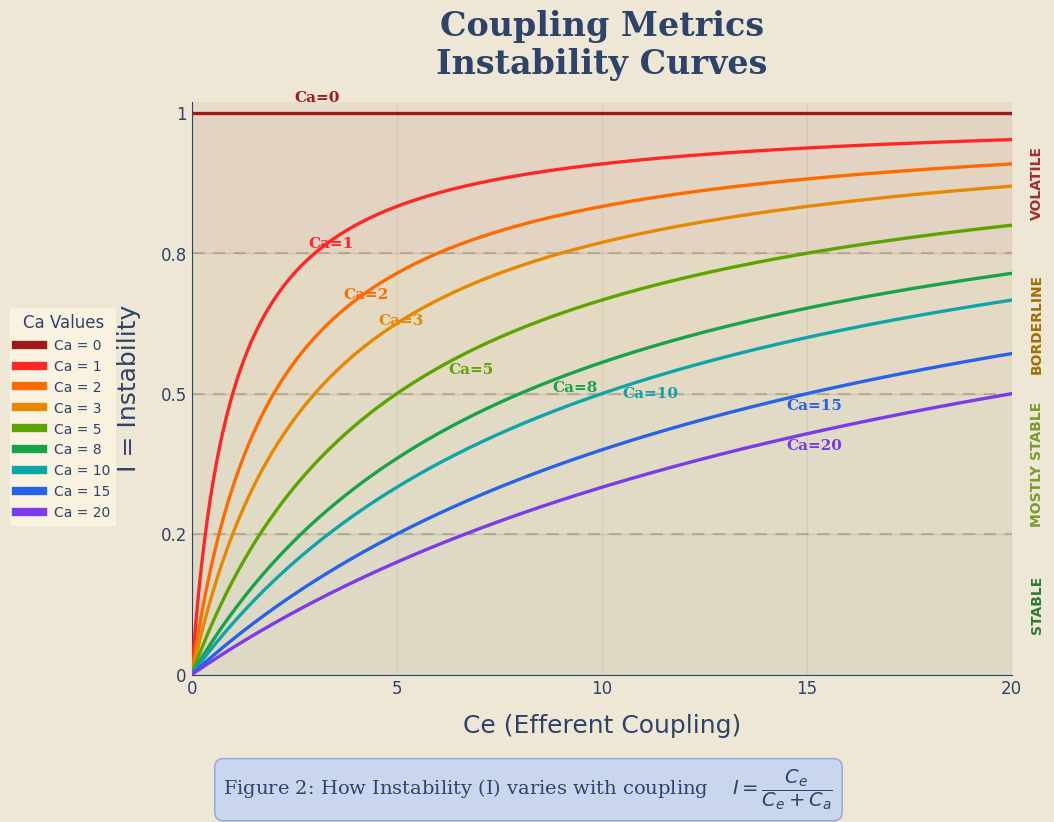

In [2]:
render_instability_curves()

### Description (Instability Curves)
TODO: Describe significance of Instability Curves


## 🧬 Abstractness (A)

This metric differentiates types as **concrete** or **abstract** (`interface`/`protocol`/`port`).


```text
A = Na / Nc
```

### Where

* ``Na`` = number of abstract types
* ``Nc`` =`total number of types


### Interpretation
* ``A = 1`` → completely abstract
* ``A = 0`` → completely concrete

### Conclusion
* Abstraction provides flexibility
* Concrete code provides behavior
* Good architecture balances both
---

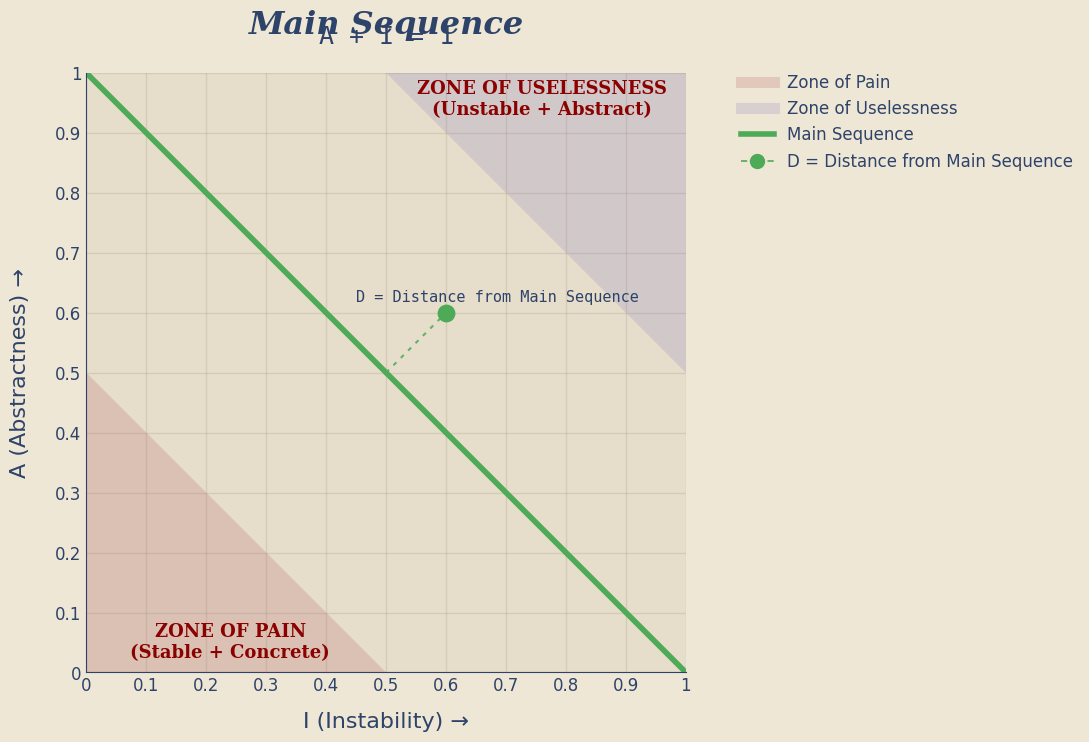

In [16]:
# ============================================================
# 📊 MAIN SEQUENCE — CONCEPTUAL VIEW
# ============================================================
render_main_sequence_conceptual()


## 🧪 The Main Sequence

When plotting **Abstractness (A)** against **Instability (I)**, something interesting appears.

Healthy modules tend to cluster along a line defined by:

```text
A + I = 1
```

This line is called the **Main Sequence**.

The first graph below is the *conceptual* view: just the main sequence and the two danger zones. It teaches the terrain first — the ideal balance line, the **Zone of Pain**, and the **Zone of Uselessness**.

The second graph adds real-ish examples and shows each module’s **distance from the main sequence**:

```text
D = |A + I − 1|
```

That distance tells us how far a module has drifted from the balance between **abstractness** and **instability**. The dotted guide lines point to the nearest point on the main sequence, making the deviation visible rather than merely numerical.


## 🪨 Architectural Danger Zones

### Zone of Pain

```text
low A
low I
```

Meaning:

```text
concrete AND stable
```

These modules are depended on by many other modules but contain little abstraction.

Examples often include:

- database schemas
- configuration systems
- foundational libraries

Changing them causes cascading impact.

Hence the name.

### Zone of Uselessness

```text
high A
high I
```

Meaning:

```text
abstract AND unstable
```

These modules contain abstractions nobody uses.

Example:

```text
12 interfaces
1 implementation
0 dependents
```

Beautiful architecture.

No real purpose.

## 🧪 Distance From the Main Sequence

Once we place real modules on the same chart, the picture gets richer.

The detailed graph below shows:

- the **main sequence**
- the two architectural danger zones
- example modules in and out of those zones
- a dotted guide line from each module to its nearest point on the main sequence
- the **distance value** (`D`) for the more interesting examples

That lets us see not just *where* a module sits, but *how far off-balance* it is.

Some modules live outside the danger zones and are still worth watching. A service layer, API gateway, or shared utility package may not be pathological, but a non-zero distance still suggests the design is drifting away from the ideal balance.


In [22]:
# ============================================================
# 📊 DISTANCE FROM MAIN SEQUENCE — DETAILED VIEW
# ============================================================
render_distance_from_main_sequence()


## 🗺️ Where These Metrics Apply

These metrics apply to many software systems:

- large monoliths
- modular applications
- plugin architectures
- libraries
- microservices

Microservice systems especially benefit from coupling analysis because dependencies often hide behind **network calls rather than imports**.

A service with high efferent coupling may rely on many downstream services.

Each dependency increases operational risk.

Understanding coupling helps prevent systems from drifting toward the dreaded:

```text
distributed monolith
```

## 🧱 The Takeaway

Architecture is often treated as an art.

But beneath the diagrams lies something more mechanical.

Software systems obey structural forces.

Coupling is one of them.

And like gravity…

you can ignore it.

But you cannot escape it.

## 📚 References

- Martin, R. C. (1994). *OO Design Quality Metrics: An Analysis of Dependencies.*
- Martin, R. C. (2017). *Clean Architecture.*
- Lakos, J. (1996). *Large-Scale C++ Software Design.*
- Ford, N., Parsons, R., & Kua, P. (2017). *Building Evolutionary Architectures.*